<a href="https://colab.research.google.com/github/Minraws-rb/AI-bootcamp/blob/main/StrokePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install if needed
!pip install -q kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

# File inside the dataset
file_path = "healthcare-dataset-stroke-data.csv"

# Load directly into a pandas DataFrame
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "fedesoriano/stroke-prediction-dataset",
    file_path
)

print(df.head())

/tmp/ipykernel_1353/3887352294.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  


In [3]:
df.shape

(5110, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
#for numerical data
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [6]:
#for categorical data
df.describe(include='object')

,gender,ever_married,work_type,Residence_type,smoking_status
count,5110,5110,5110,5110,5110
unique,3,2,5,2,4
top,Female,Yes,Private,Urban,never smoked
freq,2994,3353,2925,2596,1892


In [7]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [8]:
df.isnull().sum().sort_values(ascending=False)

,0
bmi,201
id,0
age,0
gender,0
hypertension,0
heart_disease,0
work_type,0
ever_married,0
Residence_type,0
avg_glucose_level,0


<function matplotlib.pyplot.show(close=None, block=None)>

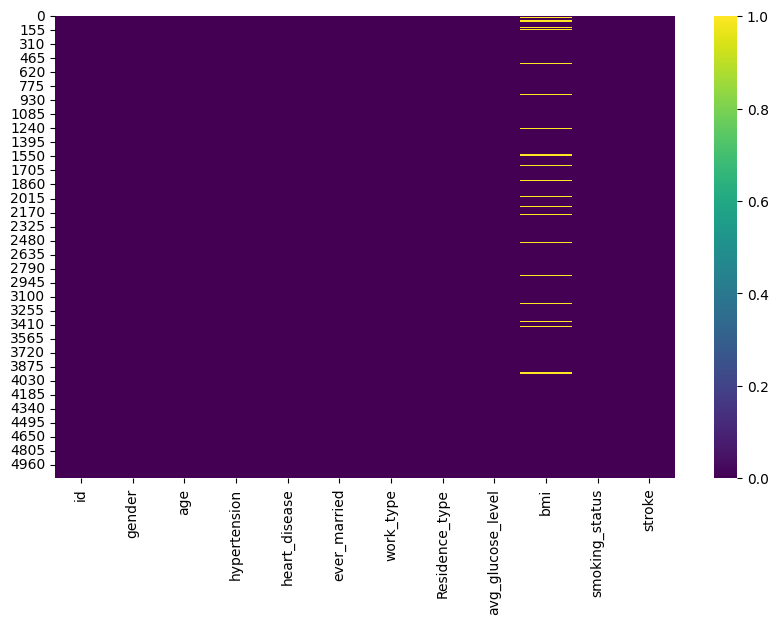

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),cmap='viridis')
plt.show

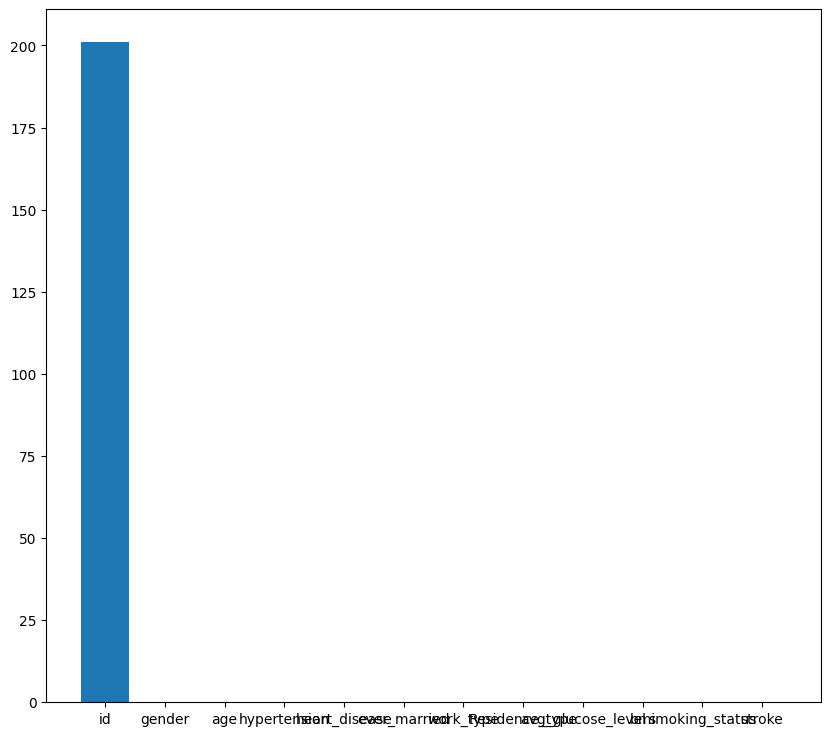

In [10]:
plt.figure(figsize=(10,9))
plt.bar(df.columns,df.isnull().sum().sort_values(ascending=False))
plt.show()

In [11]:
df.isnull().sum() / len(df) *100


,0
id,0.000000
gender,0.000000
age,0.000000
hypertension,0.000000
heart_disease,0.000000
ever_married,0.000000
work_type,0.000000
Residence_type,0.000000
avg_glucose_level,0.000000
bmi,3.933464


In [12]:
df["bmi"].describe()

,bmi
count,4909.000000
mean,28.893237
std,7.854067
min,10.300000
25%,23.500000
50%,28.100000
75%,33.100000
max,97.600000


In [13]:
print("Skewness:", df["bmi"].skew())

Skewness: 1.0553402052962912


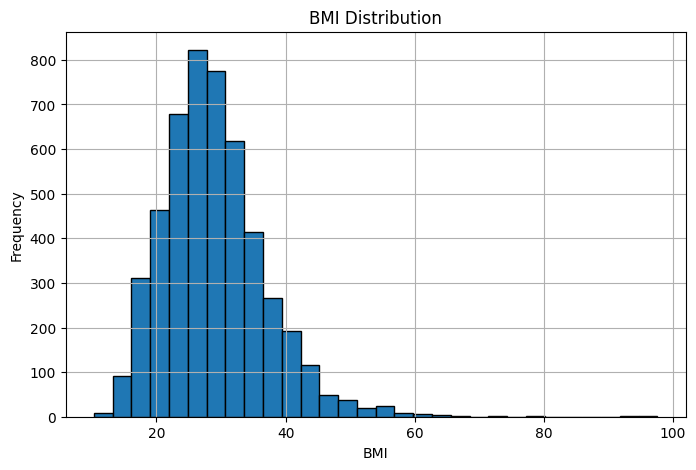

In [14]:
plt.figure(figsize=(8,5))
df["bmi"].hist(bins=30, edgecolor="black")
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

In [15]:
mean = df["bmi"].mean()
median = df["bmi"].median()
print(mean, median)

28.893236911794666 28.1


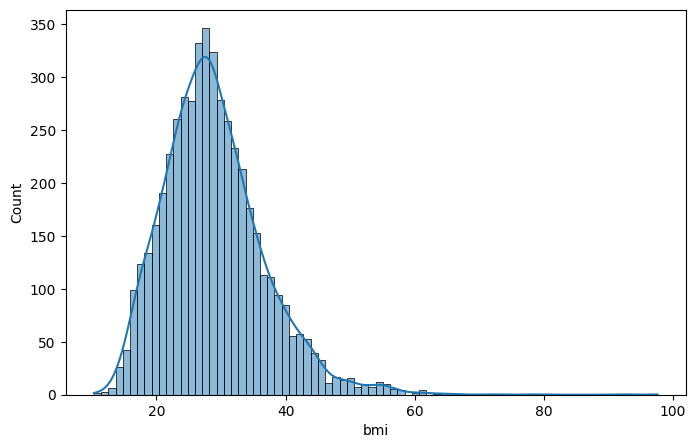

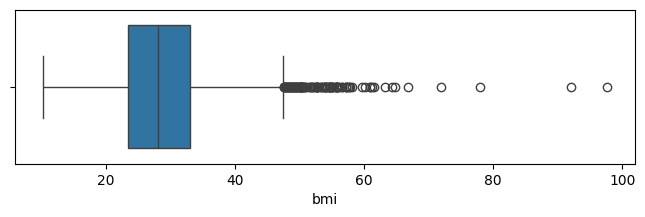

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["bmi"], kde=True)
plt.show()

plt.figure(figsize=(8,2))
sns.boxplot(x=df["bmi"])
plt.show()

In [17]:
Q1 = df["bmi"].quantile(0.25)
Q3 = df["bmi"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["bmi"] < lower) | (df["bmi"] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 110


In [18]:
df["bmi"] = df["bmi"].fillna(df["bmi"].median())
print(df["bmi"].isnull().sum())

0


In [19]:
print("Mean:", df["bmi"].mean())
print("Median:", df["bmi"].median())

Mean: 28.862035225048924
Median: 28.1


In [20]:
df.nunique()


,0
id,5110
gender,3
age,104
hypertension,2
heart_disease,2
ever_married,2
work_type,5
Residence_type,2
avg_glucose_level,3979
bmi,418


univariate analysis

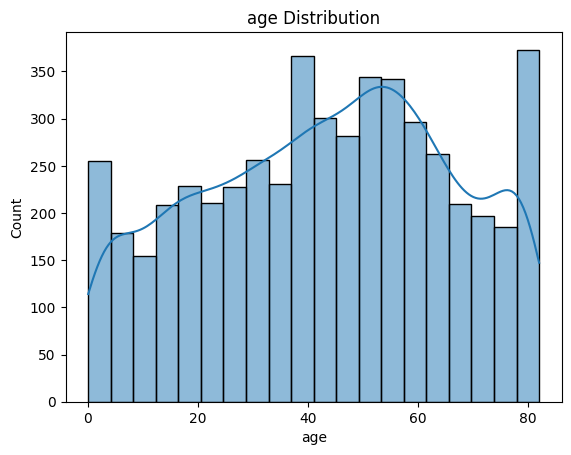

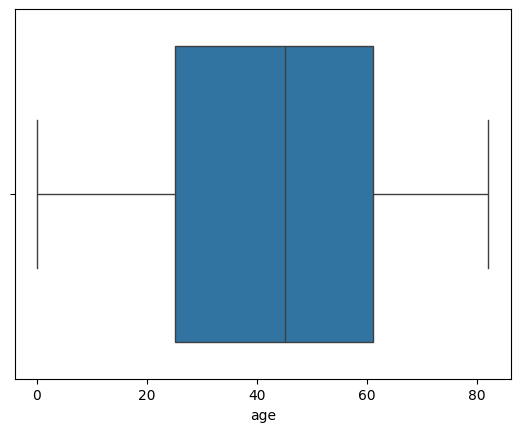

In [21]:
sns.histplot(df["age"], kde=True)
plt.title("age Distribution")
plt.show()
sns.boxplot(x=df["age"])
plt.show()

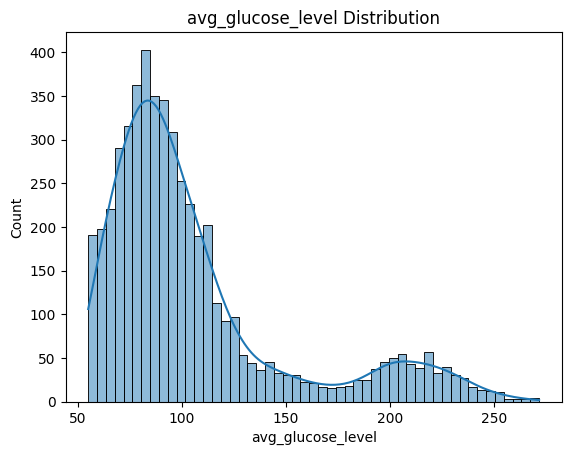

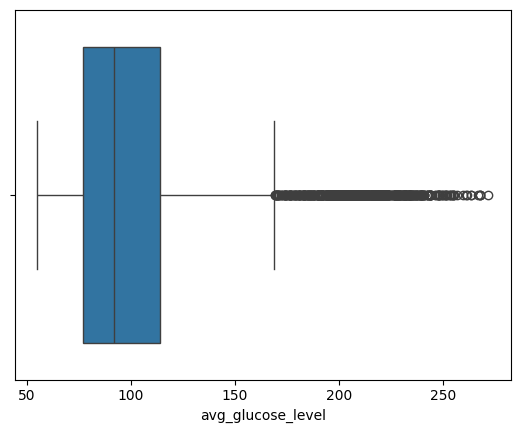

In [22]:
sns.histplot(df["avg_glucose_level"], kde=True)
plt.title("avg_glucose_level Distribution")
plt.show()
sns.boxplot(x=df["avg_glucose_level"])
plt.show()

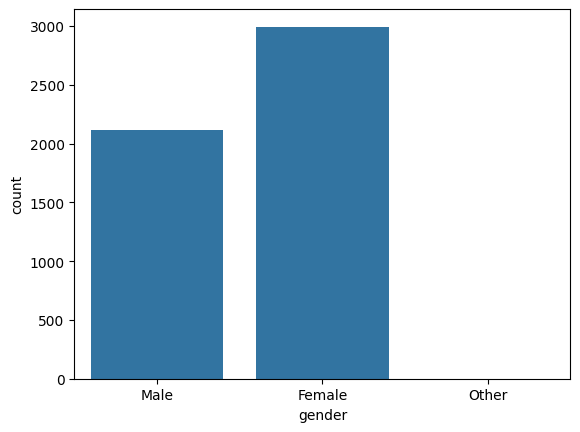

In [24]:
sns.countplot(data=df,x="gender")
plt.show()

In [25]:
#for categorical data
df.describe(include='object')

,gender,ever_married,work_type,Residence_type,smoking_status
count,5110,5110,5110,5110,5110
unique,3,2,5,2,4
top,Female,Yes,Private,Urban,never smoked
freq,2994,3353,2925,2596,1892


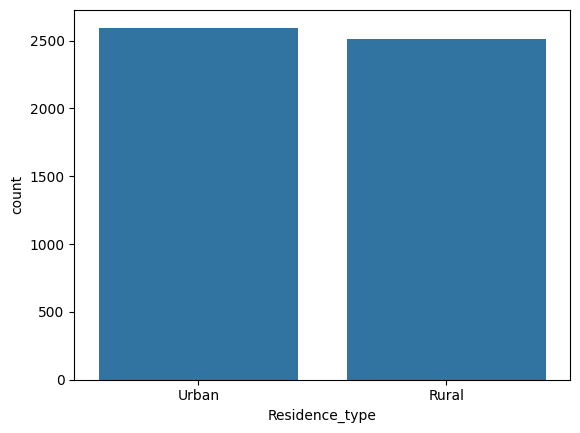

In [27]:
sns.countplot(data=df,x="Residence_type")
plt.show()

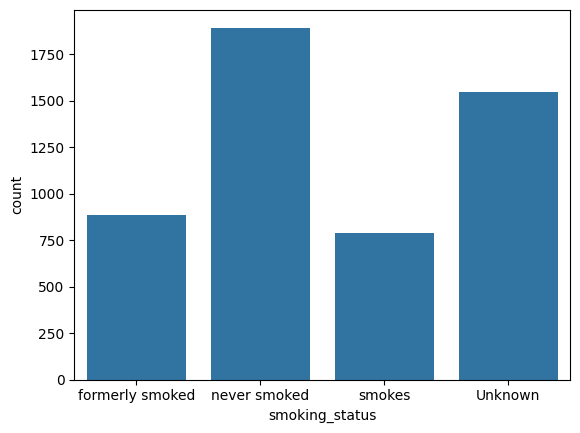

In [28]:
sns.countplot(data=df,x="smoking_status")
plt.show()

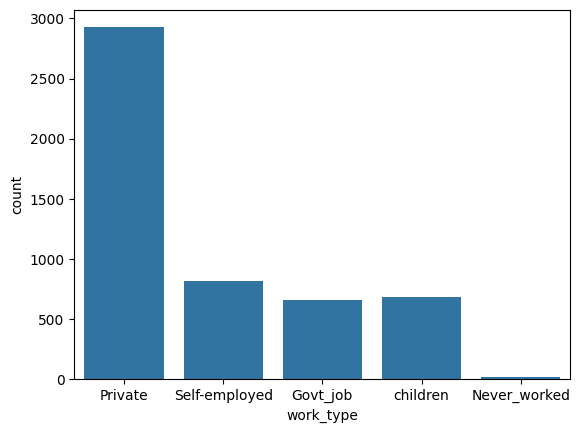

In [30]:
sns.countplot(data=df,x="work_type")
plt.show()

Age vs Stroke

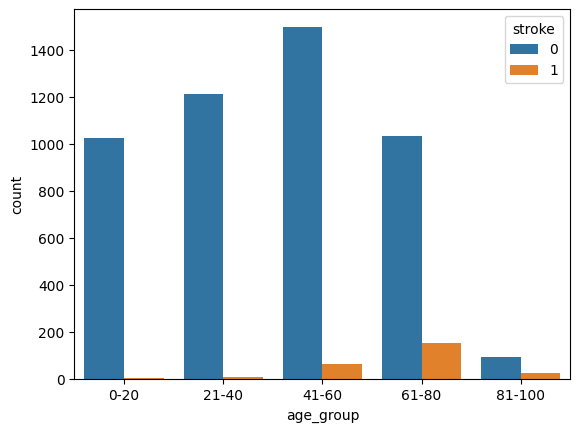

In [33]:
import pandas as pd

# Create age bins
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["0-20", "21-40", "41-60", "61-80", "81-100"],
    include_lowest=True
)

sns.countplot(
    data=df,
    x="age_group",
    hue="stroke"
)
plt.show()

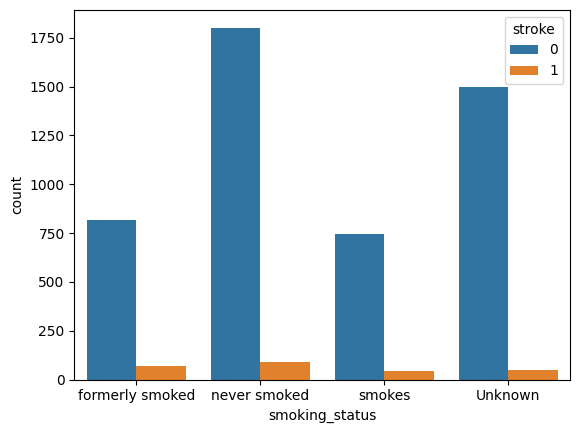

In [34]:
sns.countplot(
    data=df,
    x="smoking_status",
    hue="stroke"
)
plt.show()

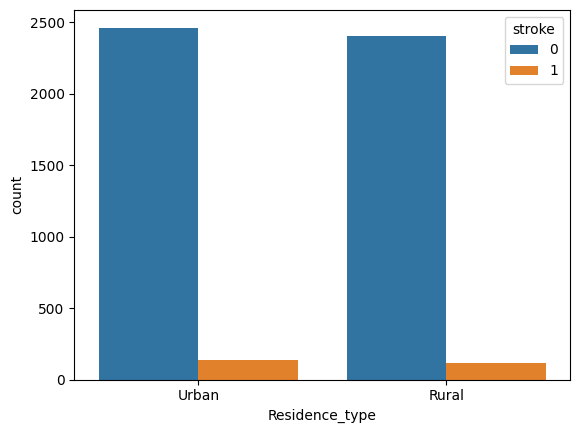

In [35]:
sns.countplot(
    data=df,
    x="Residence_type",
    hue="stroke"
)
plt.show()

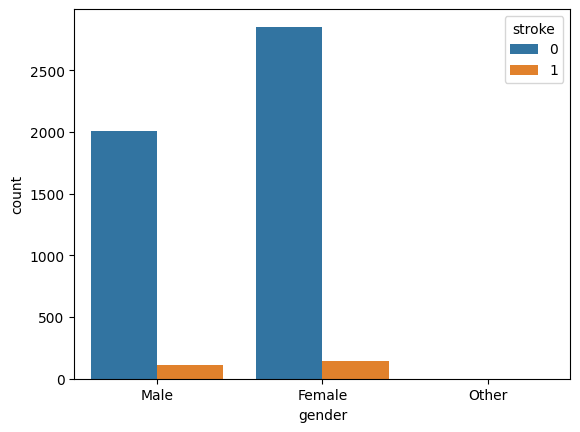

In [36]:
sns.countplot(
    data=df,
    x="gender",
    hue="stroke"
)
plt.show()

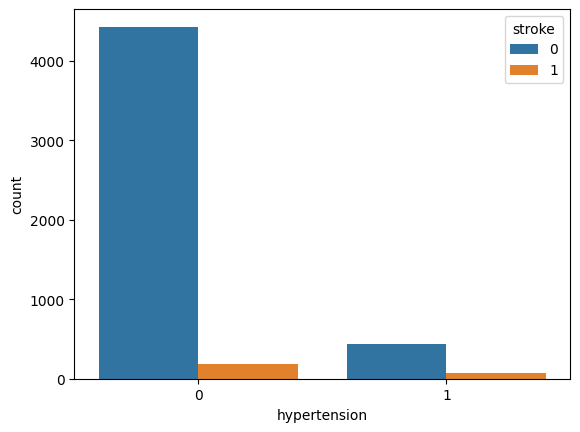

In [39]:
sns.countplot(
    data=df,
    x="hypertension",
    hue="stroke"
)
plt.show()

In [40]:
import pandas as pd

# Percentage within each hypertension group
percent = pd.crosstab(
    df["hypertension"],
    df["stroke"],
    normalize="index"   # Row-wise percentage
) * 100

print(percent.round(2))

stroke            0      1
hypertension              
0             96.03   3.97
1             86.75  13.25


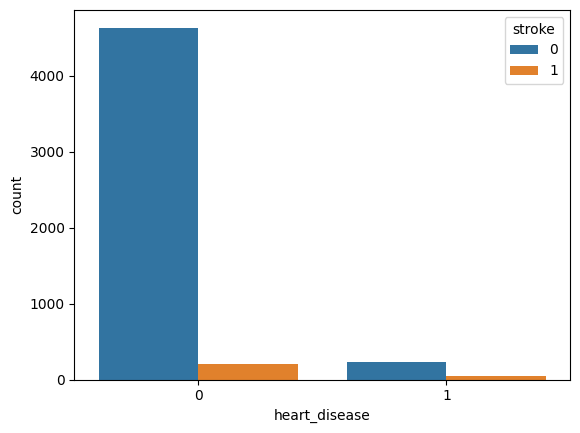

In [41]:
sns.countplot(
    data=df,
    x="heart_disease",
    hue="stroke"
)
plt.show()

In [42]:
import pandas as pd

# Percentage within each hypertension group
percent = pd.crosstab(
    df["heart_disease"],
    df["stroke"],
    normalize="index"   # Row-wise percentage
) * 100

print(percent.round(2))

stroke             0      1
heart_disease              
0              95.82   4.18
1              82.97  17.03


<Axes: >

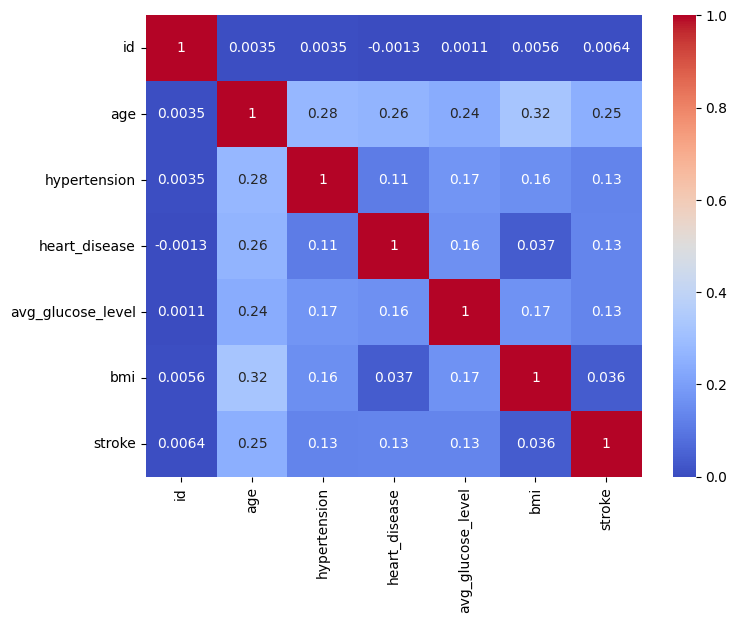

In [43]:
import numpy as np
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

In [50]:
# Find text (categorical) columns
obj_cols = df.select_dtypes(include="object").columns

# Convert those columns to one-hot encoded columns
df = pd.get_dummies(df, columns=obj_cols, drop_first=True)
df = pd.get_dummies(df, columns=["age_group"], drop_first=True)

In [51]:
X = df.drop("stroke", axis=1)

y = df["stroke"]

In [52]:
X.head()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,...,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,age_group_21-40,age_group_41-60,age_group_61-80,age_group_81-100
0,9046,67.0,0,1,228.69,36.6,True,False,True,False,...,False,False,True,True,False,False,False,False,True,False
1,51676,61.0,0,0,202.21,28.1,False,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,31112,80.0,0,1,105.92,32.5,True,False,True,False,...,False,False,False,False,True,False,False,False,True,False
3,60182,49.0,0,0,171.23,34.4,False,False,True,False,...,False,False,True,False,False,True,False,True,False,False
4,1665,79.0,1,0,174.12,24.0,False,False,True,False,...,True,False,False,False,True,False,False,False,True,False


In [53]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              5110 non-null   int64  
 1   age                             5110 non-null   float64
 2   hypertension                    5110 non-null   int64  
 3   heart_disease                   5110 non-null   int64  
 4   avg_glucose_level               5110 non-null   float64
 5   bmi                             5110 non-null   float64
 6   gender_Male                     5110 non-null   bool   
 7   gender_Other                    5110 non-null   bool   
 8   ever_married_Yes                5110 non-null   bool   
 9   work_type_Never_worked          5110 non-null   bool   
 10  work_type_Private               5110 non-null   bool   
 11  work_type_Self-employed         5110 non-null   bool   
 12  work_type_children              51

In [56]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [55]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [57]:
y_pred = model.predict(
    X_test
)

In [58]:
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [59]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9501


In [60]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



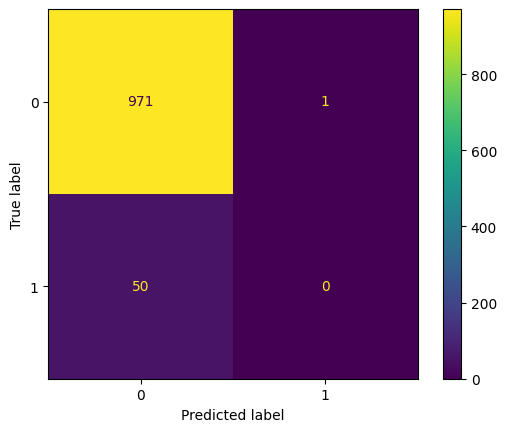

In [61]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.show()